In [1]:
import numpy as np
import torch 
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import gzip
import urllib.request as request
import os
import h5py
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from scipy.stats import wasserstein_distance
from torch.utils.data import Dataset, DataLoader, random_split
from pytorch_msssim import ssim

In [2]:
class JetsDataset(Dataset):
    def __init__(self, file_path):

        self.file_path = file_path
        
        with h5py.File(file_path, 'r') as f:
            self.X = f['X_diffusion'][:]
            self.y = f['y'][:]

        self.X = self.X - self.X.min()
            
        self.X = np.log1p(self.X)
        
        x_min = self.X.min()
        x_max = self.X.max()
        
        self.X = (self.X - x_min) / (x_max - x_min)
            
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        x = self.X[idx]
        label = self.y[idx]
        
        x = torch.tensor(x, dtype=torch.float32).permute(2, 0, 1)
            
        label = torch.tensor(int(label), dtype=torch.long)
        
        return x, label

file_path = '/Users/miguelpamanes/Library/Mobile Documents/com~apple~CloudDocs/GSoC/Diffusion_jets_procesados_2.hdf5'
full_dataset = JetsDataset(file_path=file_path)

train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

x_batch, y_batch = next(iter(test_loader))

In [3]:
def ejemplo_imagenes(images, labels):

    fig, axs = plt.subplots(ncols=len(images), nrows=1, figsize=(12,3))

    for i in range(len(images)):

        imagen_lista = np.transpose(images[i], (1, 2, 0))

        val_min = imagen_lista.min()
        val_max = imagen_lista.max()
        if val_max > val_min: 
            imagen_lista = (imagen_lista - val_min) / (val_max - val_min)

        label_val = labels[i].item() if hasattr(labels[i], 'item') else labels[i]
        
        axs[i].imshow(imagen_lista)
        axs[i].set_title(f'Label: {label_val}')

        axs[i].set_xticks([])
        axs[i].set_yticks([])
        axs[i].set_xlabel(f'Index: {i}')

    plt.tight_layout()
    plt.show()

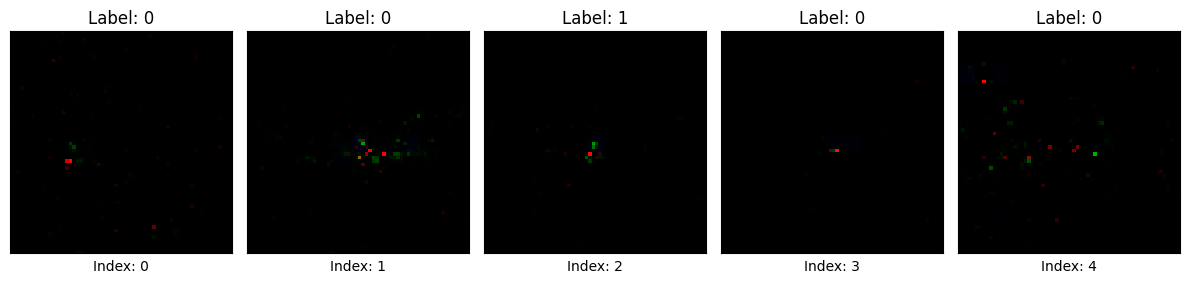

In [4]:
imagenes_ejemplo = np.stack([train_dataset[i][0].numpy() for i in range(5)])

etiquetas_ejemplo = [train_dataset[i][1] for i in range(5)]

ejemplo_imagenes(imagenes_ejemplo, etiquetas_ejemplo)

### Wassertein 1 y Radial Distribution Function

In [5]:
def ssim_loss(x_recon, x_orig):
    return 1.0 - ssim(x_recon, x_orig, data_range=1.0, size_average=True)

def wasserstein_1d_loss(x_recon, x_orig):
  
    B, C, H, W = x_recon.shape
    
    proj_x_recon = x_recon.sum(dim=1).sum(dim=1) 
    proj_x_orig = x_orig.sum(dim=1).sum(dim=1)
    proj_y_recon = x_recon.sum(dim=1).sum(dim=2) 
    proj_y_orig = x_orig.sum(dim=1).sum(dim=2)
    
    px_recon = proj_x_recon / (proj_x_recon.sum(dim=-1, keepdim=True) + 1e-8)
    px_orig = proj_x_orig / (proj_x_orig.sum(dim=-1, keepdim=True) + 1e-8)
    py_recon = proj_y_recon / (proj_y_recon.sum(dim=-1, keepdim=True) + 1e-8)
    py_orig = proj_y_orig / (proj_y_orig.sum(dim=-1, keepdim=True) + 1e-8)
    
    cdf_x_recon = torch.cumsum(px_recon, dim=-1)
    cdf_x_orig = torch.cumsum(px_orig, dim=-1)
    cdf_y_recon = torch.cumsum(py_recon, dim=-1)
    cdf_y_orig = torch.cumsum(py_orig, dim=-1)
    
    w1_x = torch.mean(torch.sum(torch.abs(cdf_x_recon - cdf_x_orig), dim=-1))
    w1_y = torch.mean(torch.sum(torch.abs(cdf_y_recon - cdf_y_orig), dim=-1))
    
    return w1_x + w1_y

class JetRadialProfileLoss(nn.Module):
    def __init__(self, img_size=64, num_bins=32, sigma=1.0, device="cuda"):
        super().__init__()
        self.num_bins = num_bins
        self.sigma = sigma
        
        x = torch.arange(img_size, device=device).float()
        y = torch.arange(img_size, device=device).float()
        grid_x, grid_y = torch.meshgrid(x, y, indexing='ij')
        
        dist_matrix = torch.sqrt((grid_x - (img_size/2 - 0.5))**2 + (grid_y - (img_size/2 - 0.5))**2)
        self.dist_matrix = dist_matrix.view(1, 1, img_size, img_size) # (1, 1, H, W)
        
        self.bin_centers = torch.linspace(0, (img_size/2) * 1.414, num_bins, device=device).view(1, 1, 1, 1, num_bins)

    def forward(self, x_recon, x_orig):
        B, C, H, W = x_recon.shape
        
        dists = self.dist_matrix.expand(B, C, H, W).unsqueeze(-1) 
        
        weights = torch.exp(-0.5 * ((dists - self.bin_centers) / self.sigma)**2) 
        
        profile_recon = (x_recon.unsqueeze(-1) * weights).sum(dim=(2, 3)) 
        profile_orig = (x_orig.unsqueeze(-1) * weights).sum(dim=(2, 3))   
        profile_recon = profile_recon / (profile_recon.sum(dim=-1, keepdim=True) + 1e-8)
        profile_orig = profile_orig / (profile_orig.sum(dim=-1, keepdim=True) + 1e-8)
        
        return F.mse_loss(profile_recon, profile_orig, reduction='mean')

### Autoencoder

In [6]:
class AutoEncoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        
        self.latent_dim = latent_dim

        #Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),

            nn.ReLU(),
            nn.Flatten()
        )

        #bottleneck
        self.bottleneck = nn.Linear(8192, latent_dim)
        self.decoder_input = nn.Linear(latent_dim, 8192)

        #Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        flat_enconded = self.encoder(x)
        latent_space = self.bottleneck(flat_enconded)

        z_projected = self.decoder_input(latent_space)
        z_reshaped = z_projected.view(-1, 128, 8, 8)

        decoded = self.decoder(z_reshaped)

        return decoded

In [7]:
def train_AutoEncoder_conv_2(dataset, learning_rate=1e-3, num_epochs=20, batch_size=128, w_ssim=10.0, w_w1=5.0, w_rdf=20.0): 
    #device = "cuda" if torch.cuda.is_available() else "cpu"
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    
    model = AutoEncoder(latent_dim=256).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    rdf_criterion = JetRadialProfileLoss(img_size=64, num_bins=32, device=device)
    mse_criterion = nn.MSELoss(reduction='sum') 
    
    train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(num_epochs):
        total_loss = 0.0
        total_mse = 0.0
        total_ssim = 0.0
        total_w1 = 0.0
        total_rdf = 0.0
        
        model.train()
        for batch_idx, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            
            decoded = model(images)
            
            loss_mse = mse_criterion(decoded, images)
            loss_ssim = ssim_loss(decoded, images)
            loss_w1 = wasserstein_1d_loss(decoded, images)
            loss_rdf = rdf_criterion(decoded, images)
            
            loss = loss_mse + (w_ssim * loss_ssim) + (w_w1 * loss_w1) + (w_rdf * loss_rdf)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_mse += loss_mse.item()
            total_ssim += loss_ssim.item()
            total_w1 += loss_w1.item()
            total_rdf += loss_rdf.item()

        n_samples = len(train_loader.dataset)
        n_batches = len(train_loader)
        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {total_loss/n_samples:.6f} | MSE: {total_mse/n_samples:.6f} | SSIM: {total_ssim/n_batches:.6f} | W1: {total_w1/n_batches:.6f} | RDF: {total_rdf/n_batches:.6f}")

    return model

In [8]:
model_ae_pets = train_AutoEncoder_conv_2(train_dataset, num_epochs=30, batch_size=64)

Epoch 1/30 | Loss: 37.045725 | MSE: 35.400472 | SSIM: 0.518998 | W1: 19.997586 | RDF: 0.003835
Epoch 2/30 | Loss: 1.082157 | MSE: 0.262639 | SSIM: 0.131728 | W1: 10.211166 | RDF: 0.002767
Epoch 3/30 | Loss: 0.351719 | MSE: 0.100010 | SSIM: 0.037253 | W1: 3.139642 | RDF: 0.001614
Epoch 4/30 | Loss: 0.144402 | MSE: 0.026249 | SSIM: 0.009040 | W1: 1.488624 | RDF: 0.001267
Epoch 5/30 | Loss: 0.107370 | MSE: 0.013247 | SSIM: 0.003147 | W1: 1.193162 | RDF: 0.001210
Epoch 6/30 | Loss: 0.094033 | MSE: 0.010567 | SSIM: 0.001760 | W1: 1.059682 | RDF: 0.001188
Epoch 7/30 | Loss: 0.084892 | MSE: 0.009764 | SSIM: 0.001374 | W1: 0.953835 | RDF: 0.001169
Epoch 8/30 | Loss: 0.078392 | MSE: 0.009363 | SSIM: 0.001262 | W1: 0.876077 | RDF: 0.001153
Epoch 9/30 | Loss: 0.072985 | MSE: 0.009007 | SSIM: 0.001218 | W1: 0.811595 | RDF: 0.001141
Epoch 10/30 | Loss: 0.068255 | MSE: 0.008641 | SSIM: 0.001185 | W1: 0.755869 | RDF: 0.001130
Epoch 11/30 | Loss: 0.064863 | MSE: 0.008292 | SSIM: 0.001156 | W1: 0.71703

In [9]:
n = 5

#device = "cuda" if torch.cuda.is_available() else "cpu"
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

with torch.no_grad():
    images, labels = next(iter(test_loader))
    images = images[:n].to(device) 

    reconstructed = model_ae_pets(images) 

images_np = images.cpu().numpy()
reconstructed_np = reconstructed.cpu().numpy()

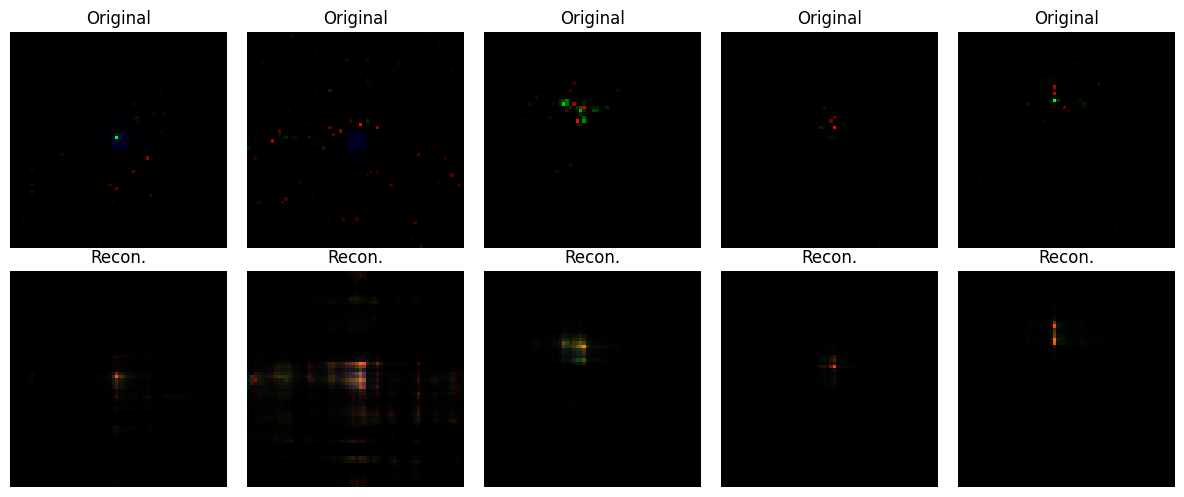

In [10]:
n = 5

fig, axes = plt.subplots(2, n, figsize=(12,5))

for i in range(n):

    img_orig = np.transpose(images_np[i], (1, 2, 0))
    img_recon = np.transpose(reconstructed_np[i], (1, 2, 0))

    min_o, max_o = img_orig.min(), img_orig.max()

    if max_o > min_o:
        img_orig = (img_orig - min_o) / (max_o - min_o)

    min_r, max_r = img_recon.min(), img_recon.max()
    if max_r > min_r:
        img_recon = (img_recon - min_r) / (max_r - min_r)

    axes[0, i].imshow(img_orig)
    axes[0, i].set_title("Original")
    axes[0, i].axis('off')

    axes[1, i].imshow(img_recon)
    axes[1, i].set_title("Recon.")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

### VAE 

In [11]:
class VAEConvolucional(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.latent_dim = latent_dim

        # ENCODER
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1), 
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Flatten() 
        )

        #Bottleneck
        self.mu = nn.Linear(8192, latent_dim)
        self.log_var = nn.Linear(8192, latent_dim)

        # DECODER
        self.decoder_input = nn.Linear(latent_dim, 8192)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid() 
        )

    def reparametrizacion(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, deterministic = False):
        hidden = self.encoder(x)
        mu = self.mu(hidden)
        log_var = self.log_var(hidden)
        
        #z = self.reparametrizacion(mu, log_var)

        if deterministic:
            z = mu
        else:
            z = self.reparametrizacion(mu, log_var)
        
        z_projected = self.decoder_input(z)
        z_reshaped = z_projected.view(-1, 128, 8, 8) 
        
        decoded = self.decoder(z_reshaped)
        return decoded, mu, log_var

### Función de Pérdida
Para este ejemplo usamos una función de pérdida que combina los parametros que estamos considerando junto con pesos asignados, para esta primer estapa los pesos fueron empiricos, pero se puede modificar para determinar si mehora el entrenamiento de la red.

In [12]:
def loss_function_conv_complete(recon_x, x, mu, log_var, rdf_criterion, beta=0.1, w_ssim=100.0, w_w1=50.0, w_rdf=500.0):
    batch_size = x.size(0)
    log_var = torch.clamp(log_var, min=-30.0, max=20.0)
    
    BCE = F.binary_cross_entropy(recon_x.view(batch_size, -1), x.view(batch_size, -1), reduction='sum') / batch_size
    KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / batch_size
    
    L_ssim = ssim_loss(recon_x, x)
    L_w1 = wasserstein_1d_loss(recon_x, x)
    L_rdf = rdf_criterion(recon_x, x)
    
    total_loss = BCE + (beta * KLD) + (w_ssim * L_ssim) + (w_w1 * L_w1) + (w_rdf * L_rdf)

    return total_loss, BCE, KLD, L_ssim, L_w1, L_rdf

In [13]:
def train_VAE_conv2(dataset, learning_rate=1e-4, num_epochs=100, batch_size=64, beta=0.1, w_ssim=100.0, w_w1=50.0, w_rdf=500.0):
    #device = "cuda" if torch.cuda.is_available() else "cpu"
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

    
    model = VAEConvolucional(latent_dim=64).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
    
    rdf_criterion = JetRadialProfileLoss(img_size=64, num_bins=32, device=device)
    
    train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(num_epochs):
        total_loss = 0.0
        total_bce = 0.0
        total_kld = 0.0
        total_ssim = 0.0
        total_w1 = 0.0
        total_rdf = 0.0
        
        model.train()
        for batch_idx, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            
            decoded, mu, log_var = model(images)
            
            loss, bce, kld, l_ssim, l_w1, l_rdf = loss_function_conv_complete(
                decoded, images, mu, log_var, rdf_criterion, 
                beta=beta, w_ssim=w_ssim, w_w1=w_w1, w_rdf=w_rdf
            )
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            total_bce += bce.item()
            total_kld += kld.item()
            total_ssim += l_ssim.item()
            total_w1 += l_w1.item()
            total_rdf += l_rdf.item()

        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]

        num_batches = len(train_loader)
        epoch_loss = total_loss / num_batches
        epoch_bce = total_bce / num_batches
        epoch_kld = total_kld / num_batches
        epoch_ssim = total_ssim / num_batches
        epoch_w1 = total_w1 / num_batches
        epoch_rdf = total_rdf / num_batches
        
        print(f'Epoch: {epoch + 1}/{num_epochs} | LR: {current_lr:.6f} | Loss: {epoch_loss:.6f} | BCE: {epoch_bce:.6f} | KLD: {epoch_kld:.6f} | SSIM: {epoch_ssim:.6f} | W1: {epoch_w1:.6f} | RDF: {epoch_rdf:.6f}')

    return model

In [14]:
model_conv = train_VAE_conv2(train_dataset, num_epochs=30, batch_size=64, beta = 0.1)

Epoch: 1/30 | LR: 0.000100 | Loss: 1506.502298 | BCE: 1019.809252 | KLD: 153.365142 | SSIM: 0.467774 | W1: 8.469320 | RDF: 0.002226
Epoch: 2/30 | LR: 0.000100 | Loss: 106.114460 | BCE: 12.827473 | KLD: 128.308722 | SSIM: 0.029112 | W1: 1.538287 | RDF: 0.001261
Epoch: 3/30 | LR: 0.000100 | Loss: 85.066008 | BCE: 5.699407 | KLD: 123.172261 | SSIM: 0.006186 | W1: 1.316256 | RDF: 0.001236
Epoch: 4/30 | LR: 0.000100 | Loss: 77.432105 | BCE: 4.675106 | KLD: 121.441823 | SSIM: 0.002137 | W1: 1.195779 | RDF: 0.001220
Epoch: 5/30 | LR: 0.000100 | Loss: 72.889281 | BCE: 4.467953 | KLD: 120.308037 | SSIM: 0.001471 | W1: 1.112772 | RDF: 0.001210
Epoch: 6/30 | LR: 0.000100 | Loss: 70.041399 | BCE: 4.413829 | KLD: 119.935500 | SSIM: 0.001332 | W1: 1.058010 | RDF: 0.001201
Epoch: 7/30 | LR: 0.000100 | Loss: 67.476959 | BCE: 4.389284 | KLD: 119.668900 | SSIM: 0.001285 | W1: 1.007928 | RDF: 0.001192
Epoch: 8/30 | LR: 0.000100 | Loss: 65.568119 | BCE: 4.374318 | KLD: 119.472307 | SSIM: 0.001262 | W1: 0.

In [15]:
#device = "cuda" if torch.cuda.is_available() else "cpu"
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

ESTADÍSTICAS GLOBALES

mu shape: torch.Size([27862, 64])
mu mean: 0.092754
mu std: 1.649493
logvar mean: -1.896057
logvar std: 1.461047

STD POR DIMENSIÓN
Dim  0: 1.054517
Dim  1: 1.281520
Dim  2: 0.957269
Dim  3: 0.996434
Dim  4: 0.952736
Dim  5: 1.630296
Dim  6: 0.849956
Dim  7: 1.079438
Dim  8: 1.048311
Dim  9: 0.954875
Dim 10: 1.104758
Dim 11: 1.271499
Dim 12: 0.875585
Dim 13: 0.930288
Dim 14: 0.898391
Dim 15: 1.252594
Dim 16: 0.942963
Dim 17: 1.079659
Dim 18: 0.942322
Dim 19: 0.886979
Dim 20: 0.938255
Dim 21: 1.051908
Dim 22: 1.173471
Dim 23: 1.004087
Dim 24: 0.739199
Dim 25: 1.211292
Dim 26: 1.009501
Dim 27: 1.368442
Dim 28: 0.888298
Dim 29: 0.934216
Dim 30: 1.073413
Dim 31: 1.041710
Dim 32: 0.859259
Dim 33: 1.544282
Dim 34: 1.000488
Dim 35: 0.990489
Dim 36: 1.037782
Dim 37: 0.853548
Dim 38: 1.041228
Dim 39: 1.113982
Dim 40: 0.925563
Dim 41: 1.207425
Dim 42: 0.972200
Dim 43: 0.951389
Dim 44: 1.081587
Dim 45: 1.027431
Dim 46: 0.988232
Dim 47: 1.895318
Dim 48: 1.060331
Dim 49: 0.85

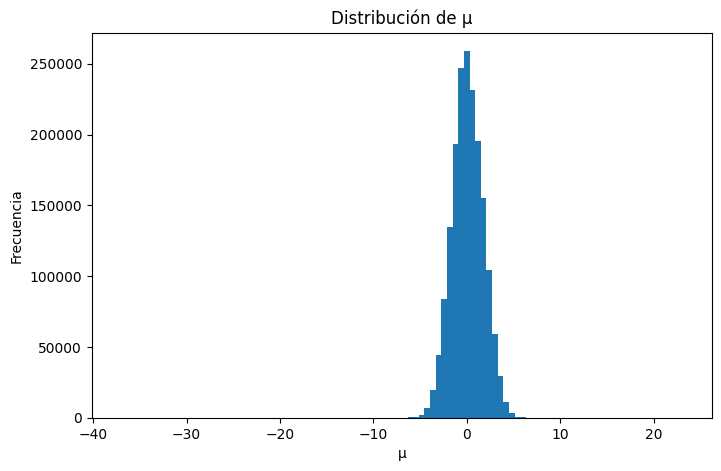

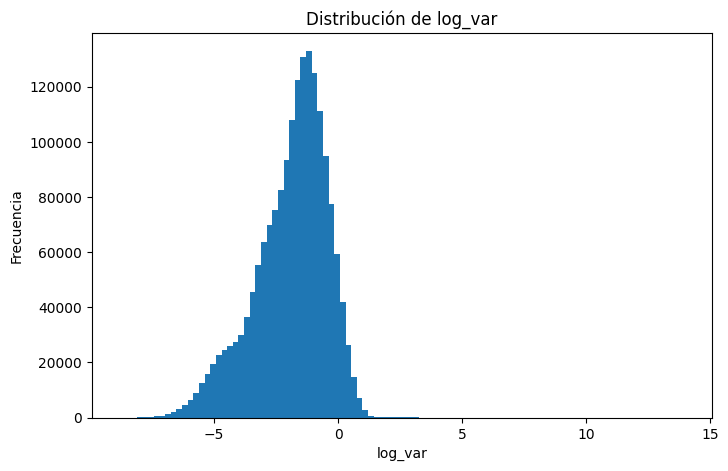

In [ ]:
model_conv.eval()

mus = []
logvars = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        _, mu, log_var = model_conv(images)

        mus.append(mu.cpu())
        logvars.append(log_var.cpu())

mus = torch.cat(mus, dim=0)
logvars = torch.cat(logvars, dim=0)

#Estadísticas
print("ESTADÍSTICAS GLOBALES\n")
print(f"mu shape: {mus.shape}")
print(f"mu mean: {mus.mean().item():.6f}")
print(f"mu std: {mus.std().item():.6f}")
print(f"logvar mean: {logvars.mean().item():.6f}")
print(f"logvar std: {logvars.std().item():.6f}")
print("\nSTD POR DIMENSIÓN")
latent_std = mus.std(dim=0)

for i, std in enumerate(latent_std):
    print(f"Dim {i:2d}: {std.item():.6f}")

#Mu
plt.figure(figsize=(8,5))
plt.hist(mus.flatten().numpy(), bins=100)
plt.xlabel("μ")
plt.ylabel("Frecuencia")
plt.title("Distribución de μ")
plt.show()
#Log_Var
plt.figure(figsize=(8,5))
plt.hist(logvars.flatten().numpy(), bins=100)
plt.xlabel("log_var")
plt.ylabel("Frecuencia")
plt.title("Distribución de log_var")
plt.show()

In [17]:
kl_per_dim = 0.5 * (mus.pow(2) + logvars.exp() - 1 - logvars)

kl_per_dim = kl_per_dim.mean(dim=0)
print(kl_per_dim)

active_dims = (kl_per_dim > 0.01).sum()
print("Active dims:", active_dims.item())

tensor([ 3.3155,  2.7981,  0.7086,  4.8925,  0.8852,  5.3054,  0.6023,  1.6811,
         3.7895,  1.2433,  1.7307,  2.7394,  0.9801,  2.3545,  0.6939,  4.3025,
         3.8838,  2.2804,  2.0755,  0.5610,  2.2461,  2.0594,  2.5268,  1.0351,
         1.7123,  2.4460,  4.0709,  5.8596,  1.0411,  1.3806,  1.9460,  3.0571,
         2.2009,  3.2781,  0.7782,  1.0756,  1.0825,  0.6306,  5.4150,  2.2680,
         0.7740,  4.0820,  1.1911,  0.6418,  4.1934,  1.1208,  2.0201,  5.9429,
         2.4952,  2.1799,  0.9582,  1.5208,  0.6181,  1.9555,  1.1323, 24.9867,
         2.6694,  1.3630,  1.8138,  0.5990,  3.0775,  8.5769,  3.0161,  1.0352])
Active dims: 64


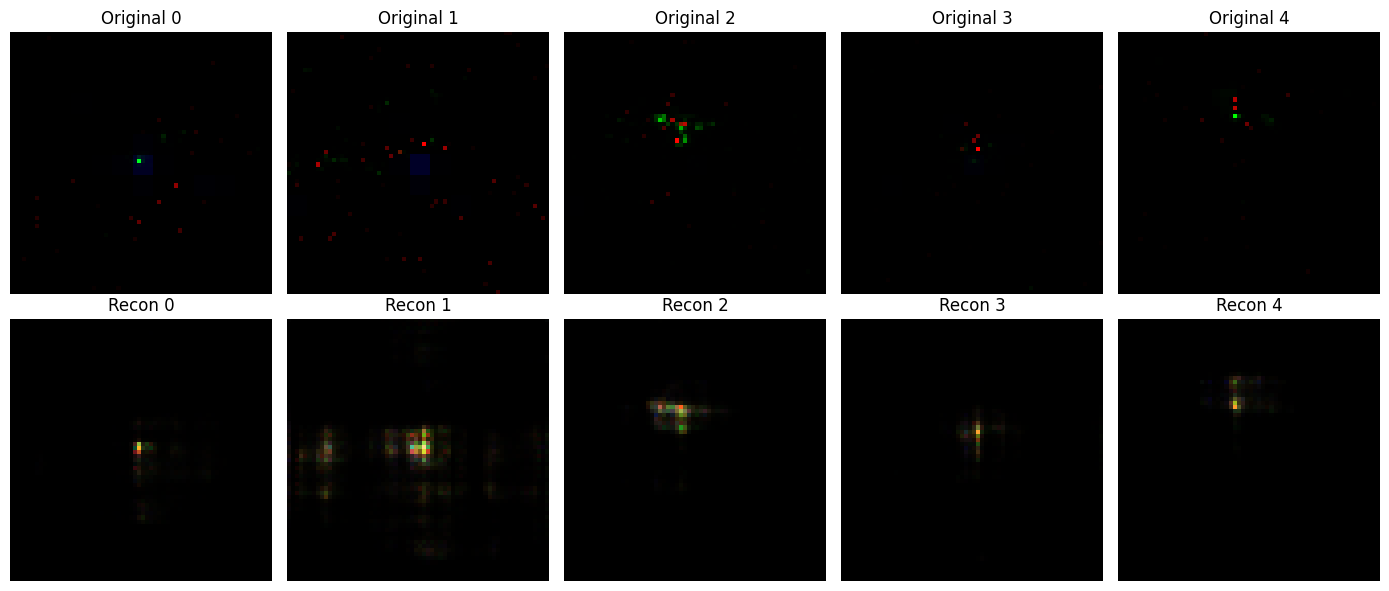

In [ ]:
#device = "cuda" if torch.cuda.is_available() else "cpu"
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model_conv.eval()

x_batch, _ = next(iter(test_loader))
x_batch = x_batch.to(device)

with torch.no_grad():

    decoded_stochastic, _, _ = model_conv(x_batch, deterministic=False)
    decoded_mu, _, _ = model_conv(x_batch, deterministic=True)

num_images = 5
fig, axes = plt.subplots(2, num_images, figsize=(14,6))

for i in range(num_images):

    img_orig = (x_batch[i].detach().cpu().numpy().transpose(1,2,0))
    img_mu = (decoded_mu[i].detach().cpu().numpy().transpose(1,2,0))

    if img_orig.max() > 0:
        img_orig = img_orig / img_orig.max()
    if img_mu.max() > 0:
        img_mu = img_mu / img_mu.max()

    img_orig = np.clip(img_orig, 0, 1)
    img_mu = np.clip(img_mu, 0, 1)

    axes[0, i].imshow(img_orig)
    axes[0, i].set_title(f"Original {i}")
    axes[0, i].axis("off")

    axes[1, i].imshow(img_mu)
    axes[1, i].set_title(f"Recon {i}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()